# Title

# Exploring this Dataset

## Overview

This dataset takes a look at the total energy consumption of all the countries in the world, with data on where they get this energy from (renewable vs fossil fuel), and what it is used for (industrial or commercial). I got this dataset from Kaggle: https://www.kaggle.com/datasets/atharvasoundankar/global-energy-consumption-2000-2024

## Data Load and Cleaning

##Setup and Imports

## Exploratory Data Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load google drive so that we can acess our dataset:

In [ ]:
dataset = pd.read_csv("/content/games_may2024_cleaned.csv")

In [ ]:
dataset.head()

,AppID,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,29018,753,6078,352,1362469,"{'FPS': 90076, 'Shooter': 64786, 'Multiplayer'...",87,8071426,80,56072
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,590582,"{'Survival': 14611, 'Shooter': 12477, 'Battle ...",58,2365012,68,19517
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,35557,1327,1163,977,668192,"{'Free to Play': 59559, 'MOBA': 19966, 'Multip...",81,2247365,71,23832
3,271590,Grand Theft Auto V,2015-04-13,17,0.00,1,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,12898,590,6910,235,133571,"{'Open World': 31998, 'Action': 23177, 'Multip...",87,1643791,92,16181
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,16213,578,3016,331,68162,"{'FPS': 9689, 'PvP': 9073, 'e-sports': 9026, '...",85,1091695,77,10566


As you can see above, there are quite a few interesting columns in this dataset. Some interesting ones i may look at are Per Capita Energy Use (Kwh per person), and Fossil Fuel Dependency, the percentage of energy used that comes from fossil fuels. While countries that use a lot of energy per capita are often more developed, it is not clear if that means they will have more renewable energy, as such amounts of energy may be cheaper coming from fossil fuels than more expensive (perhaps) renewable sources.

In [ ]:
dataset.shape

(83646, 46)

The 10000 is the amount of Country-Years (Data from one country in one specific year) in this dataset, and the 10 is the columns, spanning fossil fuel, renewables, total energy consumption, industrialvscommercial, etc...

In [ ]:
dataset.count()

,0
AppID,83646
name,83643
release_date,83646
required_age,83646
price,83646
dlc_count,83646
detailed_description,83480
about_the_game,83458
short_description,83537
reviews,10283


In [ ]:
dataset.describe()

,AppID,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,negative,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.364600e+04,83646.000000,83646.000000,83646.000000,83646.000000,83646.000000,8.364600e+04,83646.000000,41.000000,8.364600e+04,8.364600e+04,83646.000000,83646.000000,83646.000000,83646.000000,8.364600e+04,83646.000000,8.364600e+04,83646.000000,83646.000000
mean,1.421850e+06,0.276403,7.492446,0.580542,3.451080,20.702735,1.003478e+03,0.037467,99.121951,1.276726e+03,2.072231e+02,79.663044,3.634364,65.152572,3.744925,9.927115e+01,45.985223,1.345631e+03,5.596191,18.757430
std,7.480058e+05,2.119835,13.094604,14.179160,15.685104,167.839222,2.108173e+04,1.737074,0.748168,3.057663e+04,5.792324e+03,1018.506902,74.621737,933.278070,82.321592,5.914524e+03,40.607112,3.411672e+04,22.911354,1155.763735
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,7.922225e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.373005e+06,0.000000,4.990000,0.000000,0.000000,4.000000,0.000000e+00,0.000000,99.000000,1.100000e+01,3.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,60.000000,1.600000e+01,-1.000000,-1.000000
75%,2.014495e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,6.400000e+01,1.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,84.000000,8.700000e+01,-1.000000,-1.000000
max,2.984570e+06,21.000000,999.980000,3165.000000,97.000000,9821.000000,4.111974e+06,100.000000,100.000000,7.024836e+06,1.029779e+06,95816.000000,6836.000000,110101.000000,9874.000000,1.362469e+06,100.000000,8.071426e+06,100.000000,321958.000000


<Axes: xlabel='required_age', ylabel='Count'>

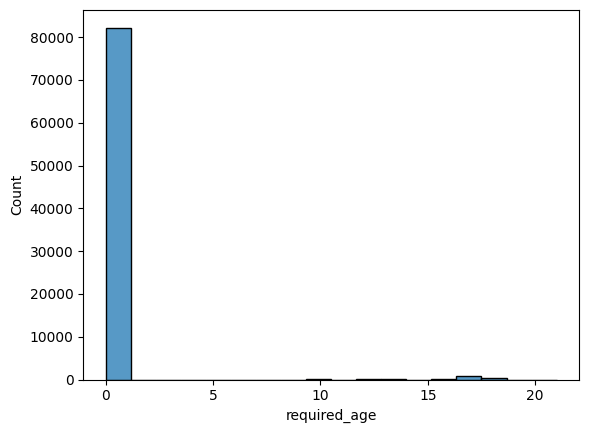

In [ ]:
sns.histplot(dataset["required_age"])

<Axes: xlabel='price', ylabel='Count'>

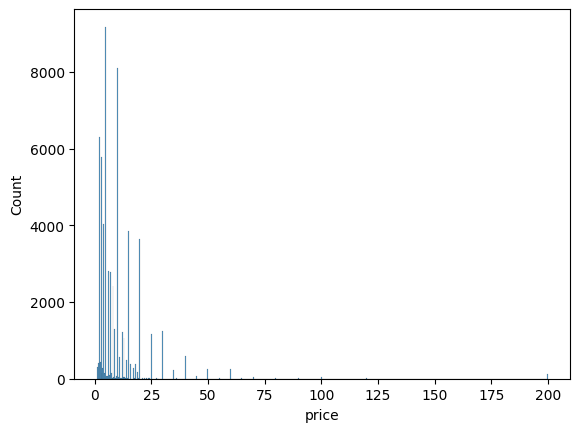

In [ ]:
highprice1 = dataset[(dataset['price'] > 1) & (dataset['price'] < 200)]
sns.histplot(highprice1["price"])

<Axes: xlabel='price', ylabel='dlc_count'>

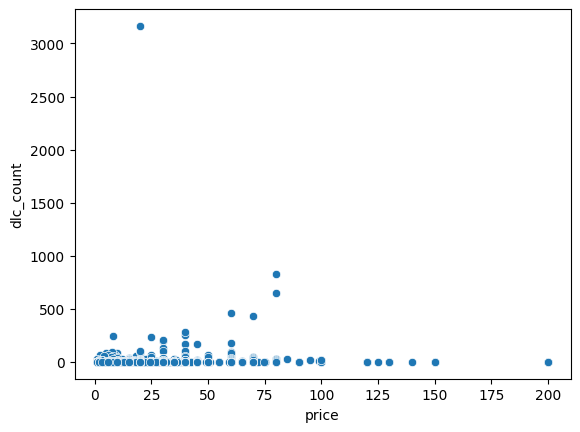

In [ ]:
sns.scatterplot(x=highprice1['price'], y=highprice1["dlc_count"])

In [ ]:
highprice1['year'] = highprice1['release_date'].str[0:4].astype(int)*365
highprice2 = highprice1
highprice2['year'] = highprice1['release_date'].str[0:4].astype(int)*365
highprice2['year'] += highprice2['release_date'].str[5:7].astype(int)*30
highprice2['year'] += highprice2['release_date'].str[8:10].astype(int)
highprice2['year'] = highprice2['year'] / 365

/tmp/ipykernel_2957/3597733533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highprice1['year'] = highprice1['release_date'].str[0:4].astype(int)*365
/tmp/ipykernel_2957/3597733533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highprice2['year'] = highprice1['release_date'].str[0:4].astype(int)*365
/tmp/ipykernel_2957/3597733533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

<Axes: xlabel='year', ylabel='price'>

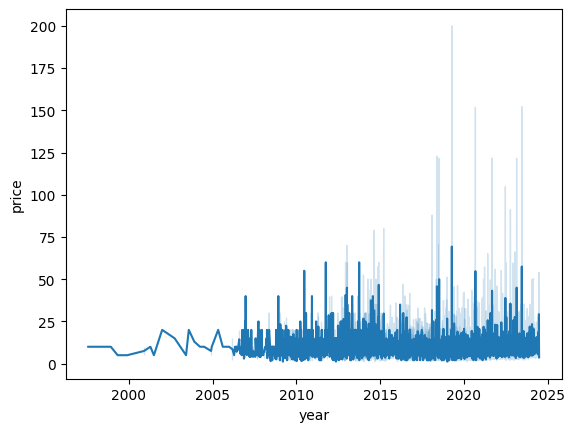

In [ ]:
sns.lineplot(data=highprice2, x="year", y="price")

<Axes: xlabel='price', ylabel='pct_pos_total'>

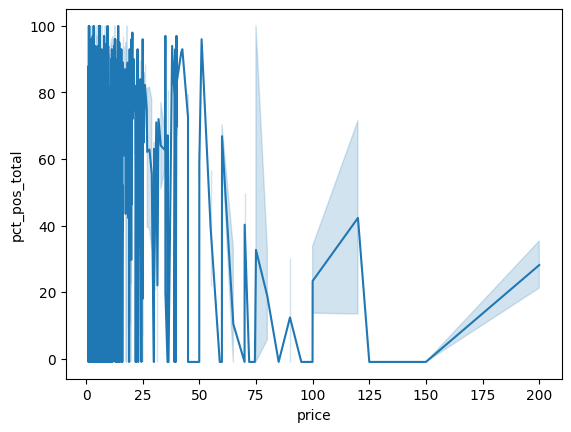

In [ ]:
sns.lineplot(data=highprice2, x="price", y="pct_pos_total")

[]

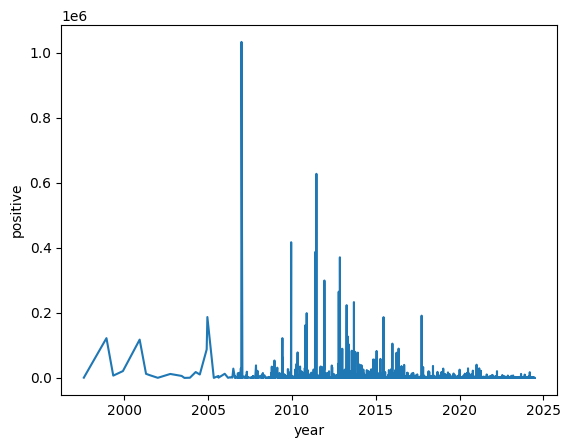

In [ ]:
highprice4 = highprice2
aggprice = highprice4.groupby("year")["positive"].mean().reset_index()
sns.lineplot(data=aggprice, x="year", y="positive")
plt.plot(linewidth=1)

In [ ]:

top_years = highprice2.groupby("year")["positive"].sum().nlargest(5)
print(top_years)

highprice2[highprice2["year"] == 2008].nlargest(10, "positive")[["name", "positive"]]

year
2011.454795    1255370
2015.989041    1160155
2006.983562    1033373
2018.186301     927471
2009.947945     834542
Name: positive, dtype: int64


,name,positive


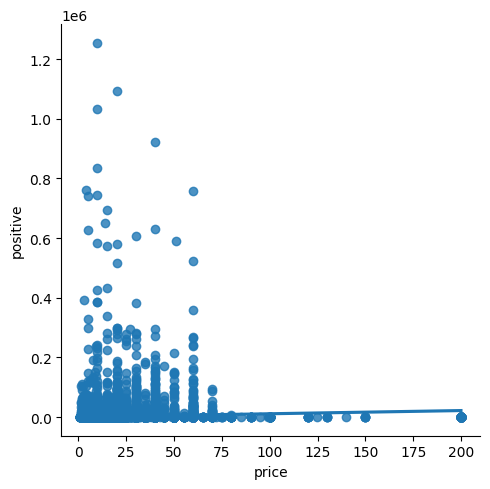

In [ ]:
sns.lmplot(data=highprice1, x="price", y="positive")

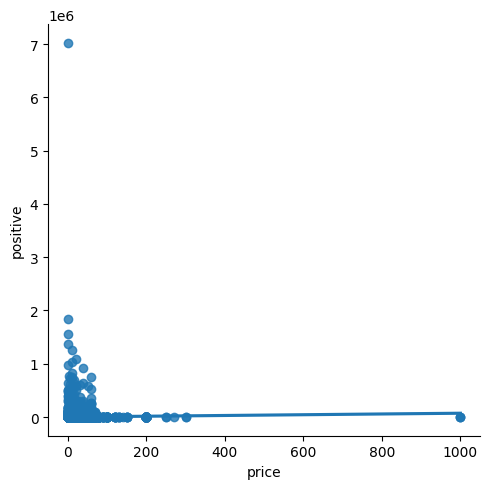

In [ ]:
sns.lmplot(data=dataset, x=(("price")), y="positive")

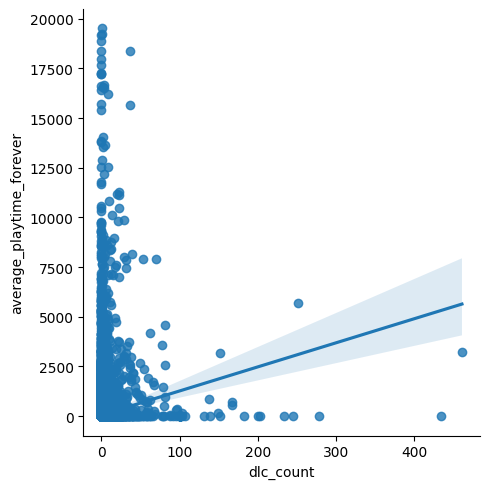

In [ ]:
avgplaytimelow = dataset[(dataset['average_playtime_forever'] < 20000)]
avgplaytimelow = avgplaytimelow[(avgplaytimelow['dlc_count'] < 600)]
sns.lmplot(data=avgplaytimelow, x="dlc_count", y="average_playtime_forever")

In [ ]:
cleanset1 = highprice1[highprice1['user_score'] > 10]
sns.scatterplot(data=cleanset1, x="price", y="user_score")

In [ ]:
sns.lmplot(data=cleanset1, x="price", y="user_score")

In [ ]:
sns.lmplot(data=dataset, x="price", y="user_score")
plt.xlim(right = 400)

In [ ]:
sns.histplot(dataset["dlc_count"])

In [ ]:
sns.histplot(dataset["metacritic_score"])

None of these first histplots were anything special, and things seemed surprisingly linear, as there were about as many countries with low energy consumption than high consumption, etc.. However, the most interesting one was Energy Price Index, where there were more countries with exceptionally low energy prices, and also more with exceptionally high prices.

In [ ]:
sns.histplot(dataset["score_rank"])

In [ ]:
highprice2.groupby('year').size().plot()

In [ ]:
yearlything = dataset
yearlything['year'] = dataset['release_date'].str[0:4].astype(int)
yearlything = yearlything[yearlything['year'] > 2010]
yearlything.groupby('year')[['mac', 'linux']].mean().multiply(100).plot()
plt.ylabel('% of Releases')

In [ ]:
yearlythi = dataset
yearlythi = yearlythi[yearlythi['dlc_count']<100]
yearlythi.groupby('dlc_count')['average_playtime_forever'].mean().plot()

In [ ]:
cleanset1 = dataset[dataset['user_score'] > 0]
sns.histplot(cleanset1["user_score"])

In [ ]:
sns.lmplot(data=cleanset1, x="num_reviews_total", y="price")

In [ ]:
sns.scatterplot(data=cleanset1, x="num_reviews_total", y="price")

In [ ]:
sns.lineplot(data=highprice4, x="num_reviews_total", y = 'mac')

In [ ]:
yearly = highprice1.groupby('year')[["windows", 'mac', 'linux']].mean().multiply(100)
yearly.plot()

## Background Information & Questions

## Loading & Exploratory Data Analysis

## Analysis



## Conclusions